# Variational Autoencoder

Is it possible to generate data using a standard Autoencoder?

## Autoencoder (AE)

**Autoencoder (AE)** is a neural network designed to learn an identity function in an unsupervised way.\
The goal is to reconstruct the original input while compressing the data.\
In the end, this model discovers a more efficient and compressed representation (like PCA).

<img src="images/ae_architecture.png" alt="ae_architecture" width="800"/>

The parameters $\theta$ and $\phi$ are learned together to output a reconstructed data sample same as the original input.\
They could be learned with, _e.g._, MSE loss:

$$\mathcal{L}_{\text{AE}} (\theta, \phi) = \cfrac{1}{n}\sum\limits_{i = 1}^n \Bigl[\mathbf{x}^{(i)} - f_{\theta}\bigl(g_{\phi} \bigl(\mathbf{x}^{(i)} \bigr)\bigr) \Bigr]^2$$

The fundamental problem with AEs, for generation, is that the latent space they convert their inputs to\
and where their encoded vectors lie, may not be continuous, or allow easy interpolation.

<div style="text-align: right">
    <div style="font-size: 12px">
    Images courtesy of [Lil’Log](https://lilianweng.github.io/posts/2018-08-12-vae/)
    </div>
</div>

## Variational Autoencoder (VAE)

**VAEs** solve this issue by making the embedding space continuous by design:

<img src="images/vae_architecture.png" alt="vae_architecture" width="800"/>

The idea of **Variational Autoencoder** was introduced by [Kingma & Welling](https://arxiv.org/abs/1312.6114) in 2014.\
Instead of mapping the input into a fixed vector, we want to map it into a distribution.

<div style="text-align: right">
    <div style="font-size: 12px">
    Images courtesy of [Lil’Log](https://lilianweng.github.io/posts/2018-08-12-vae/)
    </div>
</div>

### Imports

In [1]:
import os
import torch
import torchvision
import matplotlib.pyplot as plt

from einops import rearrange
from tqdm.notebook import tqdm

from utils import make_reproducible

### Global Variables

In [2]:
DATA_PATH = os.path.join(".", "data")
CHECKPOINT_DIR = os.path.join(".", "checkpoints")

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

#### Reproducibility

In [3]:
make_reproducible(seed=0)

### Dataset

We will use [MNIST](http://yann.lecun.com/exdb/mnist/) (handwritten digits) dataset.\
The images are centered in a $28\times 28$ image by computing the center of mass of the pixels,\
and translating the image so as to position this point at the center of the $28\times 28$ field.

In [4]:
train_dataset = torchvision.datasets.MNIST(root=DATA_PATH, train=True, transform=torchvision.transforms.ToTensor(), download=True)
val_dataset = torchvision.datasets.MNIST(root=DATA_PATH, train=False, transform=torchvision.transforms.ToTensor(), download=True)

IMAGE_SHAPE = (1, 28, 28)

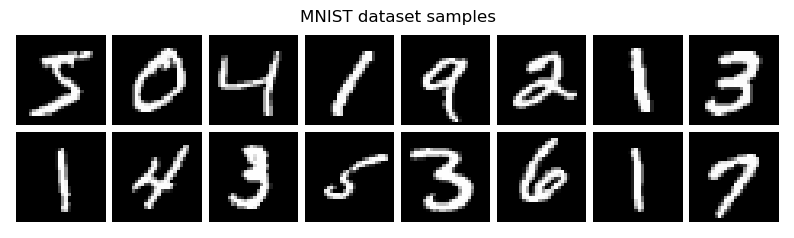

In [5]:
NUM_IMAGES = 16

images = [train_dataset[index][0] for index in range(NUM_IMAGES)]
images_grid = torchvision.utils.make_grid(images, nrow=NUM_IMAGES // 2, normalize=True, pad_value=1)
images_grid = rearrange(images_grid, "c h w -> h w c")

plt.figure(figsize=(10, 5))
plt.title("MNIST dataset samples")
plt.imshow(images_grid)
plt.axis('off')
plt.show()

### Loss Function

The optimal $\theta^*$ parameters are those that maximize the probability of generating real data samples (Maximum Likelihood):

$$\theta^* = \arg\max\limits_{\theta}\prod\limits_{i = 1}^n p_{\theta}(\mathbf{x}^{(i)}) = \arg\max\limits_{\theta}\sum\limits_{i = 1}^n \log p_{\theta}(\mathbf{x}^{(i)})$$

We can compute $p_{\theta}(\mathbf{x}^{(i)})$ by marginalizing over latent variable $z$:

$$p_{\theta}(\mathbf{x}^{(i)}) = \int p_{\theta}(\mathbf{x}^{(i)} | \mathbf{z})p_{\theta}(\mathbf{z})~d\mathbf{z}$$

However, it is **very expensive to check all the possible values** of $\mathbf{z}$ and sum them up!\
This is why we introduce a new approximation function $q_{\phi}(\mathbf{z} | \mathbf{x})$ to output what is a likely code given an input $\mathbf{x}$:

<img src="images/vae_probabilistic.png" alt="vae_probabilistic" width="600"/>

* The conditional probability $p_{\theta}(\mathbf{x} | \mathbf{z})$ defines a generative model (_aka_ probabilistic decoder).
* The approximation function $q_{\phi}(\mathbf{z} | \mathbf{x})$ is the probabilistic encoder.

The estimated posterior $q_{\phi}(\mathbf{z} | \mathbf{x})$ should be very close to the real one $p_{\theta}(\mathbf{z} | \mathbf{x})$.\
To accomplish this we can minimize the [KL divergence](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence) $D_{\text{KL}} \bigl(q_{\phi}(\mathbf{z} | \mathbf{x})~||~p_{\theta}(\mathbf{z} | \mathbf{x}) \bigr)$.

We have

$$D_{\text{KL}} \bigl(q_{\phi}(\mathbf{z} | \mathbf{x})~||~p_{\theta}(\mathbf{z} | \mathbf{x}) \bigr) = \log p_{\theta}(\mathbf{x}) + D_{\text{KL}} \bigl(q_{\phi}(\mathbf{z} | \mathbf{x})~||~p_{\theta}(\mathbf{z}) \bigr) - \mathbb{E}_{z \sim q_{\phi}(\mathbf{z} | \mathbf{x})} \log p_{\theta}(\mathbf{x} | \mathbf{z})$$
 
So, we define our loss function as

$$\mathcal{L}_{\text{VAE}}(\theta, \phi) = \min\limits_{\theta, \phi} \Bigl[-\log p_{\theta}(\mathbf{x}) + D_{\text{KL}} \bigl(q_{\phi}(\mathbf{z} | \mathbf{x})~||~p_{\theta}(\mathbf{z} | \mathbf{x}) \bigr) \Bigr] = \min\limits_{\theta, \phi} \Bigl[ - \mathbb{E}_{z \sim q_{\phi}(\mathbf{z} | \mathbf{x})} \log p_{\theta}(\mathbf{x} | \mathbf{z}) + D_{\text{KL}} \bigl(q_{\phi}(\mathbf{z} | \mathbf{x})~||~p_{\theta}(\mathbf{z}) \bigr) \Bigr]$$

We choose

* $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$ and
* $q_{\phi}(\mathbf{z} | \mathbf{x}) = \mathcal{N}(\mu, \sigma^2 \mathbf{I})$ (a multivariate Gaussian with a diagonal covariance structure).

This means that

$$D_{\text{KL}} \bigl(q_{\phi}(\mathbf{z} | \mathbf{x})~||~p_{\theta}(\mathbf{z}) \bigr) = -\cfrac{1}{2} \Bigl[\log \sigma^2 - \sigma^2 - \mu^2 + 1 \Bigr]$$

<div style="text-align: right">
    <div style="font-size: 12px">
    Images courtesy of [Lil’Log](https://lilianweng.github.io/posts/2018-08-12-vae/)
    </div>
</div>

In [6]:
class VAELoss(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.binary_cross_entropy = torch.nn.functional.binary_cross_entropy

    def forward(self, input_tensor, reconstructed_tensor, z_mean, z_log_variance):
        bce_loss = # YOUR CODE
        kl_divergence = # YOUR CODE
    
        loss = # YOUR CODE
    
        return loss

    def compute_kl_divergence(self, z_mean, z_log_variance):
        # YOUR CODE

### Model

The encoder and decoder can be any reasonable neural networks.

However, the expectation term in the loss function invokes generating samples $\mathbf{z} \sim q_{\phi}(\mathbf{z} | \mathbf{x})$.\
**Sampling is a stochastic process** and therefore **we cannot perform gradient backpropagation!**

#### Reparameterization Trick

To make it trainable, the **reparameterization trick** is introduced:

Instead of sampling $\mathbf{z} \sim q_{\phi}(\mathbf{z} | \mathbf{x}) = \mathcal{N}(\mu, \sigma^2 \mathbf{I})$ we do $\mathbf{z} = \mu + \sigma \odot \varepsilon$, where $\varepsilon \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$

<img src="images/reparameterization_trick.png" alt="reparameterization_trick" width="600"/>

In [7]:
class VAE(torch.nn.Module):
    def __init__(self, image_shape, hidden_dim=400, latent_dim=200):
        super().__init__()
        
        self.image_shape = image_shape
        self.input_dim = # YOUR CODE

        self.encoder = # input_dim --> hidden_dim --> latent_dim
        
        self.to_mean = torch.nn.Linear(latent_dim, 2)
        self.to_log_variance = torch.nn.Linear(latent_dim, 2)

        self.decoder = # 2 --> latent_dim --> hidden_dim --> input_dim --> sigmoid

    def forward(self, tensor):
        z_mean, z_log_variance = self.encode(tensor)
        
        z = self.sample_normal(z_mean, z_log_variance)
        
        out_tensor = self.decode(z)
        
        return out_tensor, z_mean, z_log_variance
     
    def encode(self, tensor):
        # YOUR CODE

    def decode(self, tensor):
        # YOUR CODE

    def sample_normal(self, mean, log_variance):
        std = # YOUR CODE
        epsilon = # YOUR CODE

        return # YOUR CODE

### Training

In [8]:
class Trainer(object):
    def __init__(self, model, objective_function, optimizer, device, checkpoint_dir):
        self.model = model
        self.objective_function = objective_function
        self.optimizer = optimizer
        
        self.device = device
        
        self.checkpoint_dir = checkpoint_dir

    def train(self, train_dataloader, val_dataloader, num_epochs):
        train_losses = []
        val_losses = []
        for epoch in range(1, num_epochs + 1):
            train_loss = self.run_epoch(dataloader=train_dataloader, epoch=epoch, phase='train')
            val_loss = self.run_epoch(dataloader=val_dataloader, epoch=epoch, phase='val')

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            self.save_checkpoint(epoch=epoch)

        return train_losses, val_losses

    def run_epoch(self, dataloader, epoch, phase):
        is_train = (phase == 'train')

        self.model.train() if is_train else self.model.eval()

        running_loss = 0.0
        with torch.set_grad_enabled(is_train):
            for item in tqdm(iterable=dataloader, desc=f"Epoch {epoch:02} | {phase}", leave=False, unit='batch'):
                image_tensor, _ = item
                image_tensor = image_tensor.to(self.device)

                reconstructed_tensor, z_mean, z_log_variance = self.model(image_tensor.to(self.device))
                
                loss = self.objective_function(image_tensor, reconstructed_tensor, z_mean, z_log_variance)
                running_loss += loss.item()

                if is_train:
                    self._optimize(loss)

        running_loss = running_loss/len(dataloader)

        return running_loss

    def _optimize(self, objective):
        self.optimizer.zero_grad()
        objective.backward()
        self.optimizer.step()

    def save_checkpoint(self, epoch):
        checkpoint = {'epoch': epoch,
                      'model_state_dict': self.model.state_dict(),
                      'optimizer_state_dict': self.optimizer.state_dict()}

        os.makedirs(self.checkpoint_dir, exist_ok=True)
        torch.save(checkpoint, os.path.join(self.checkpoint_dir, "model.pth.tar"))

In [9]:
BATCH_SIZE = 256
NUM_WORKERS = 8

HIDDEN_DIM = 400
LATENT_DIM = 200


train_dataloader = torch.utils.data.DataLoader(train_dataset,
                                               batch_size=BATCH_SIZE,
                                               shuffle=True,
                                               drop_last=True,
                                               pin_memory=True,
                                               num_workers=NUM_WORKERS)
val_dataloader = torch.utils.data.DataLoader(val_dataset,
                                             batch_size=BATCH_SIZE,
                                             shuffle=False,
                                             drop_last=False,
                                             pin_memory=True,
                                             num_workers=NUM_WORKERS)

model = VAE(image_shape=IMAGE_SHAPE, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM)
model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1.0e-3, weight_decay=1.0e-4)
objective_function = VAELoss()

In [10]:
trainer = Trainer(model=model,
                  objective_function=objective_function,
                  optimizer=optimizer,
                  device=DEVICE,
                  checkpoint_dir=CHECKPOINT_DIR)

In [11]:
NUM_EPOCHS = 200

train_losses, val_losses = trainer.train(train_dataloader=train_dataloader,
                                         val_dataloader=val_dataloader,
                                         num_epochs=NUM_EPOCHS)

Epoch 01 | train:   0%|          | 0/234 [00:00<?, ?batch/s]

Epoch 01 | val:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 02 | train:   0%|          | 0/234 [00:00<?, ?batch/s]

Epoch 02 | val:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 03 | train:   0%|          | 0/234 [00:00<?, ?batch/s]

...

Epoch 198 | val:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 199 | train:   0%|          | 0/234 [00:00<?, ?batch/s]

Epoch 199 | val:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 200 | train:   0%|          | 0/234 [00:00<?, ?batch/s]

Epoch 200 | val:   0%|          | 0/40 [00:00<?, ?batch/s]

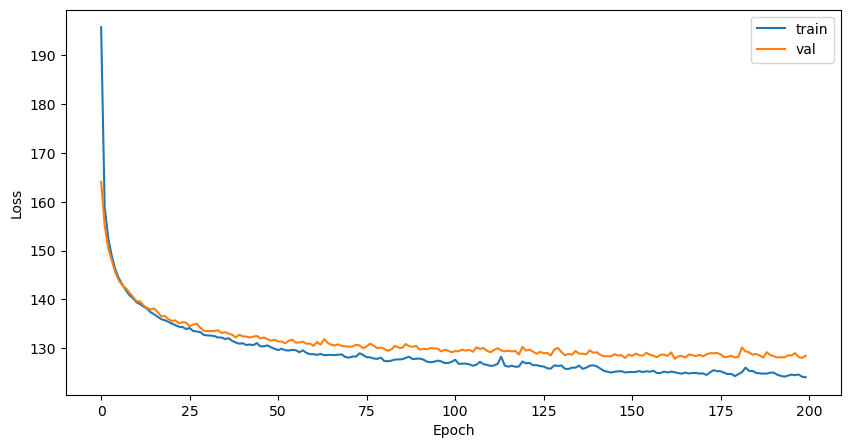

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.show()

### Let's Generate Digits

In [20]:
def load_checkpoint(checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    epoch = checkpoint.get('epoch')
    model_state_dict = checkpoint.get('model_state_dict')
    optimizer_state_dict = checkpoint.get('optimizer_state_dict')

    return epoch, model_state_dict, optimizer_state_dict

In [21]:
epoch, model_state_dict, optimizer_state_dict = load_checkpoint(checkpoint_path=os.path.join(CHECKPOINT_DIR, "pretrained_model.pth.tar"),
                                                                device=DEVICE)
model = VAE(image_shape=IMAGE_SHAPE, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM)
model.to(DEVICE)
model.load_state_dict(model_state_dict)
model.eval();

In [22]:
def show_generated_digit(model, mean, log_variance, device, figsize):
    z_sample = # YOUR CODE
    digit = # YOUR CODE

    plt.figure(figsize=figsize)
    plt.imshow(digit[0][0], cmap='gray')
    plt.axis('off')
    plt.show()

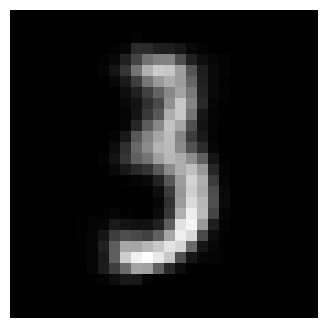

In [23]:
show_generated_digit(model=model, mean=[0.0, 0.0], log_variance=[1.0, 1.0], device=DEVICE, figsize=(4, 4))

### VAE Latent Space Visualization

In [24]:
import numpy as np

In [25]:
def plot_latent_space(model, device, digit_size=28, scale=1.0, num_samples=25, figsize=(15, 15)):
    figure = np.zeros((digit_size * num_samples, digit_size * num_samples))

    grid_x = np.linspace(-scale, scale, num_samples)
    grid_y = np.linspace(-scale, scale, num_samples)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
            digit = model.decode(z_sample).detach().cpu()
            
            figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit[0][0]

    plt.figure(figsize=figsize)
    plt.title("VAE Latent Space")
    
    start_range = digit_size // 2
    end_range = num_samples * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    
    plt.xlabel("z [0]")
    plt.ylabel("z [1]")
    
    plt.imshow(figure, cmap="gray")
    plt.show()

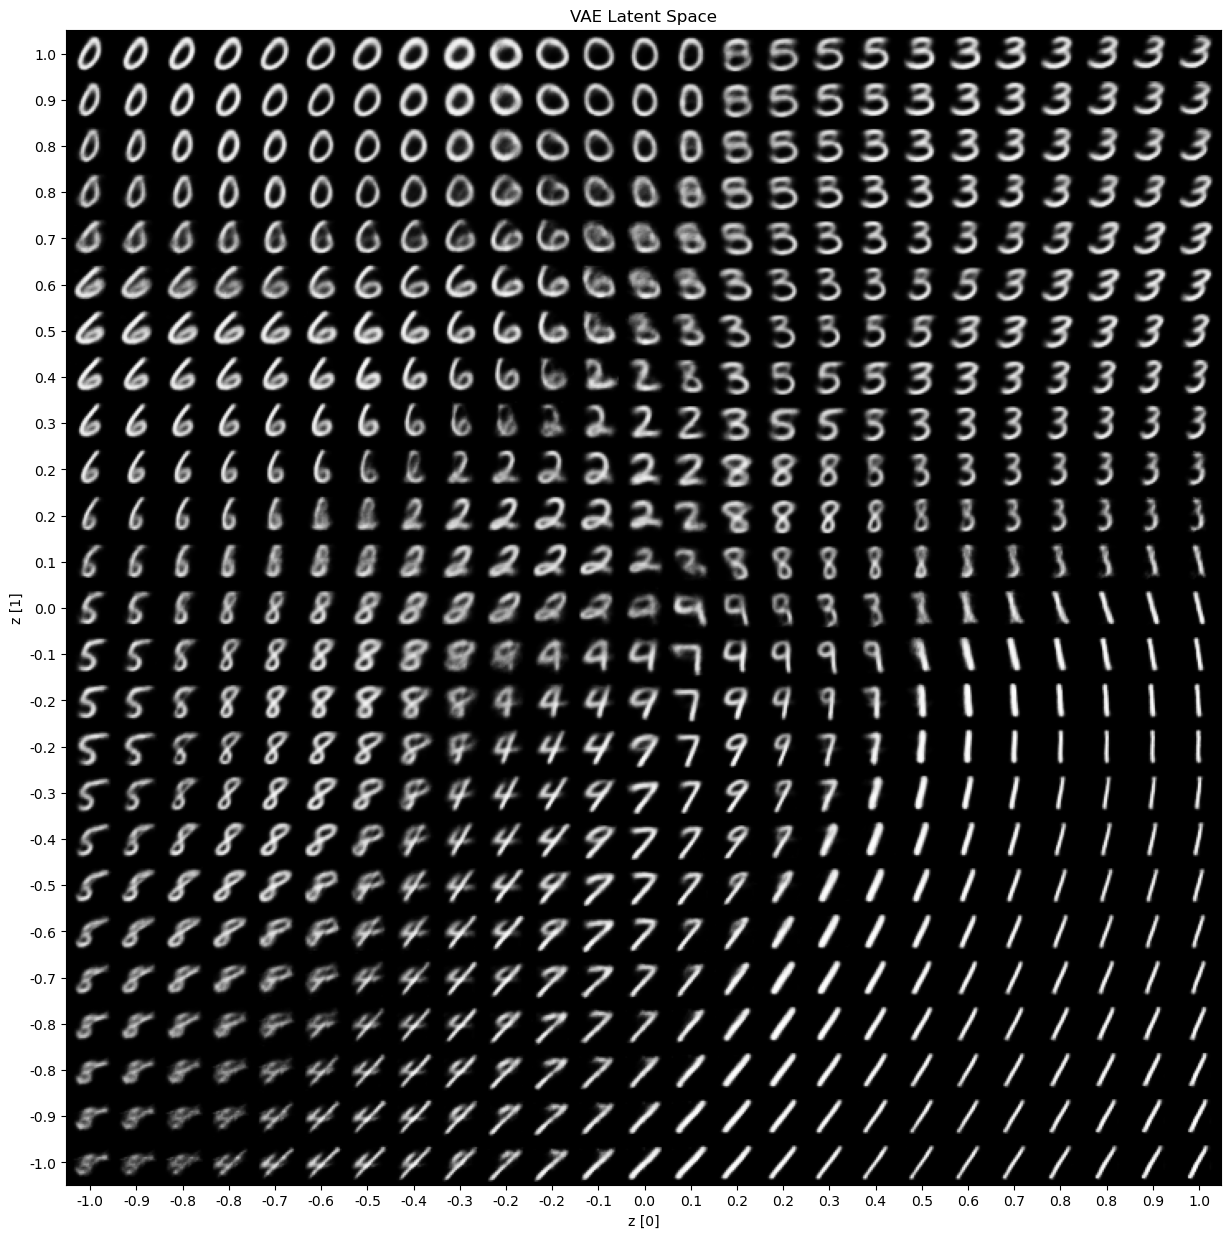

In [26]:
plot_latent_space(model, device=DEVICE, digit_size=28, scale=1.0, num_samples=25, figsize=(15, 15))